Task 1 — Simple Linear Regression

    RPM  Temperature
0  4174    81.717143
1  4507   102.148928
2  1860    44.183989
3  2294    44.163712
4  2130    33.528134
MSE: 96.07437758213023


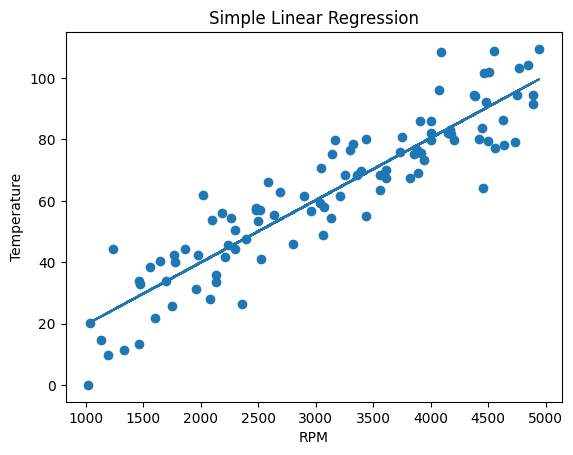

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
np.random.seed(42)
rpm = np.random.randint(1000, 5000, 100)
temperature = 0.02 * rpm + np.random.normal(0, 10, 100)
df = pd.DataFrame({
    'RPM': rpm,
    'Temperature': temperature
})
print(df.head())
X = df[['RPM']]
y = df['Temperature']
model = LinearRegression()
model.fit(X, y)
prediction = model.predict(X)
mse = mean_squared_error(y, prediction)
print("MSE:", mse)
plt.scatter(df['RPM'], df['Temperature'])
plt.plot(df['RPM'], prediction)
plt.xlabel("RPM")
plt.ylabel("Temperature")
plt.title("Simple Linear Regression")
plt.show()

Task 2 — Multivariable Regression


In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
np.random.seed(42)
rpm = np.random.randint(1000, 5000, 100)
vibration = np.random.uniform(0.1, 5.0, 100)
pressure = np.random.uniform(20, 100, 100)
temperature = (
    0.02 * rpm +
    5 * vibration +
    0.5 * pressure +
    np.random.normal(0, 10, 100)
)
df = pd.DataFrame({
    'RPM': rpm,
    'Vibration': vibration,
    'Pressure': pressure,
    'Temperature': temperature
})
print(df.head())
X = df[['RPM', 'Vibration', 'Pressure']]
y = df['Temperature']
model = LinearRegression()
model.fit(X, y)
prediction = model.predict(X)
mse = mean_squared_error(y, prediction)
print("MSE:", mse)

    RPM  Vibration   Pressure  Temperature
0  4174   4.227195  70.748108   130.494840
1  4507   2.303795  74.456436   132.918221
2  1860   2.036236  62.474767    77.506524
3  2294   4.640628  55.822653    79.503774
4  2130   3.663633  64.231447    79.619852
MSE: 115.6685125316978


Task 3 — Save Model using Pickle and Joblib

In [3]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import pickle
import joblib
np.random.seed(42)
rpm = np.random.randint(1000, 5000, 100)
vibration = np.random.uniform(0.1, 5.0, 100)
pressure = np.random.uniform(20, 100, 100)
temperature = (
    0.02 * rpm +
    5 * vibration +
    0.5 * pressure
)
df = pd.DataFrame({
    'RPM': rpm,
    'Vibration': vibration,
    'Pressure': pressure,
    'Temperature': temperature
})
X = df[['RPM', 'Vibration', 'Pressure']]
y = df['Temperature']
model = LinearRegression()
model.fit(X, y)
with open("temperature_model.pkl", "wb") as file:
    pickle.dump(model, file)
print("Pickle Model Saved!")
joblib.dump(model, "temperature_model.joblib")
print("Joblib Model Saved!")
with open("temperature_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)
prediction = loaded_model.predict([[3000, 2.5, 60]])
print(prediction)

Pickle Model Saved!
Joblib Model Saved!
[102.5]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Task 4 — One Hot Encoding

In [4]:
import pandas as pd
df = pd.DataFrame({
    'Machine_Mode': [
        'Eco',
        'Standard',
        'High-Speed',
        'Eco',
        'Standard'
    ]
})
print(df)
mode = pd.get_dummies(
    df['Machine_Mode'],
    drop_first=True
)
print(mode)
df = pd.concat([df, mode], axis=1)
print(df)
df = df.drop('Machine_Mode', axis=1)
print(df)

  Machine_Mode
0          Eco
1     Standard
2   High-Speed
3          Eco
4     Standard
   High-Speed  Standard
0       False     False
1       False      True
2        True     False
3       False     False
4       False      True
  Machine_Mode  High-Speed  Standard
0          Eco       False     False
1     Standard       False      True
2   High-Speed        True     False
3          Eco       False     False
4     Standard       False      True
   High-Speed  Standard
0       False     False
1       False      True
2        True     False
3       False     False
4       False      True


Task 5 — Train Test Split

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
np.random.seed(42)
rpm = np.random.randint(1000, 5000, 100)
vibration = np.random.uniform(0.1, 5.0, 100)
pressure = np.random.uniform(20, 100, 100)
temperature = (
    0.02 * rpm +
    5 * vibration +
    0.5 * pressure
)
df = pd.DataFrame({
    'RPM': rpm,
    'Vibration': vibration,
    'Pressure': pressure,
    'Temperature': temperature
})
X = df[['RPM', 'Vibration', 'Pressure']]
y = df['Temperature']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
prediction = model.predict(X_test)
mse = mean_squared_error(y_test, prediction)
print("MSE:", mse)

MSE: 6.563322731438818e-28


Task 6 — Logistic Regression

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
np.random.seed(42)
rpm = np.random.randint(1000, 5000, 100)
vibration = np.random.uniform(0.1, 5.0, 100)
pressure = np.random.uniform(20, 100, 100)
defective = (
    (vibration > 4)
).astype(int)
df = pd.DataFrame({
    'RPM': rpm,
    'Vibration': vibration,
    'Pressure': pressure,
    'Defective': defective
})
print(df.head())
X = df[['RPM', 'Vibration', 'Pressure']]
y = df['Defective']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = LogisticRegression()
model.fit(X_train, y_train)
prediction = model.predict(X_test)
print(prediction)
score = model.score(X_test, y_test)
print("Accuracy:", score)
matrix = confusion_matrix(y_test, prediction)
print(matrix)
report = classification_report(
    y_test,
    prediction
)
print(report)

    RPM  Vibration   Pressure  Defective
0  4174   4.227195  70.748108          1
1  4507   2.303795  74.456436          0
2  1860   2.036236  62.474767          0
3  2294   4.640628  55.822653          1
4  2130   3.663633  64.231447          0
[0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0]
Accuracy: 1.0
[[18  0]
 [ 0  2]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00         2

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

